# GME Scaling on IQM Emerald — with Threshold Filtering + Parity QREM

**Question**: how many qubits can we certify as GME on real IQM Emerald hardware?

**Two upgrades over the naive sweep:**

1. **Threshold-filter bad qubits before enumeration.** The IQM device reports per-qubit T1, T2, readout fidelity, 1Q gate fidelity, and per-CZ-pair fidelity. Qubits below thresholds (e.g. T2 < 5 µs, readout < 0.90, CZ < 0.90) are excluded *before* we enumerate sub-grids. This avoids the case where a single broken qubit drags W below the bound.

2. **Parity readout error mitigation (parity QREM).** Each stabilizer ⟨g_i⟩ depends only on the parity of {i} ∪ N(i). Per-qubit readout errors factorize, giving multiplicative correction factors c_i = 1/(P(0|0) + P(1|1) − 1) computed directly from device-reported error rates — no extra calibration circuits needed.

**Method**: same depth-3 cluster-state circuit + 2-setting GME witness as before. We use VF2 subgraph isomorphism to find contiguous rectangular sub-grids over the *threshold-passing* qubits, then score them with IQM's CostEvaluator.

**Sweep**: 3×3 → 3×5 (9 → 15 qubits) — the 3-row strips that survive moderate filtering. Above 3×5, broken qubits sit on the only available paths.

GME is certified when **W > n − 1** at significance > 3σ.

In [1]:
import sys, os, time
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile

from src.backend import (get_backend, is_simulator, select_best_subgrid,
                          get_qubit_metrics)
from src.circuits.cluster_2d import build_cluster_2d_no_measure
from src.witnesses.gme_cluster import build_gme_circuits, compute_gme_witness, gme_significance
from src.mitigation.parity_qrem import (correction_factors_from_metrics,
                                         apply_qrem_to_stabilizers)

# Stage 1: 2-row strip sweep — many sub-grid candidates exist for each.
GRID_SIZES = [(2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8)]
SHOTS = 1500

THRESHOLDS = dict(
    min_readout_fidelity=0.90,
    min_one_q_fidelity=0.99,
    min_t1=10e-6,
    min_t2=5e-6,
    min_cz_fidelity=0.90,
)

backend = get_backend(device='emerald')
print(f'Backend: {backend}')
print(f'Hardware: {not is_simulator(backend)}')
print(f'Sweep: {[r*c for r,c in GRID_SIZES]} qubits, {SHOTS} shots/circuit')
print(f'Thresholds: {THRESHOLDS}')

if not is_simulator(backend):
    qm, cz_pairs = get_qubit_metrics(backend)
    correction_factors = correction_factors_from_metrics(qm)
    cf_vals = sorted(correction_factors.values())
    print(f'\nDevice metrics: {len(qm)} qubits, {len(cz_pairs)} CZ pairs')
    print(f'QREM correction factors: median={np.median(cf_vals):.3f}, '
          f'min={cf_vals[0]:.3f}, max={cf_vals[-1]:.3f}')
else:
    correction_factors = {}

Backend: <iqm.qiskit_iqm.iqm_provider.IQMBackend object at 0x00000235D6AB1520>
Hardware: True
Sweep: [6, 8, 10, 12, 14, 16] qubits, 1500 shots/circuit
Thresholds: {'min_readout_fidelity': 0.9, 'min_one_q_fidelity': 0.99, 'min_t1': 1e-05, 'min_t2': 5e-06, 'min_cz_fidelity': 0.9}



Device metrics: 54 qubits, 81 CZ pairs
QREM correction factors: median=1.032, min=1.012, max=1.747


## Run the sweep

One IQM job per grid size: 2 circuits (settings A and B) submitted as a batch.
Each result row records W, the biseparable bound n−1, the violation, and the per-qubit stabilizer values.

In [2]:
results = []
for rows, cols in GRID_SIZES:
    n = rows * cols
    print(f'\n{rows}×{cols} = {n} qubits ...', flush=True)
    try:
        state = build_cluster_2d_no_measure(rows, cols)
        circ_a, circ_b = build_gme_circuits(state, rows, cols)

        depth_logical = circ_a.depth()
        n_cz_logical = circ_a.count_ops().get('cz', 0)

        # Threshold-filter qubits, then enumerate sub-grids over survivors,
        # then score with IQM cost evaluator.
        t_sel = time.time()
        layout, layout_cost, n_candidates = select_best_subgrid(
            backend, rows, cols, readout_mode='fidelity',
            apply_thresholds=True, **THRESHOLDS)
        sel_time = time.time() - t_sel
        print(f'  Selected ({n_candidates} candidates): {layout}  cost={layout_cost:.4f}')

        transpiled = transpile([circ_a, circ_b], backend=backend,
                               initial_layout=layout, optimization_level=3)
        depth_phys = transpiled[0].depth()
        n_cz_phys = transpiled[0].count_ops().get('cz', 0)

        t0 = time.time()
        job = backend.run(transpiled, shots=SHOTS)
        job_id = None
        try: job_id = job.job_id()
        except Exception: pass
        raw = job.result().get_counts()
        elapsed = time.time() - t0

        counts_a, counts_b = (raw, raw) if isinstance(raw, dict) else (raw[0], raw[1])
        res = compute_gme_witness(counts_a, counts_b, rows, cols)

        # Raw witness values (no mitigation)
        W_raw = res['W']
        sigma_raw = gme_significance(W_raw, n, SHOTS)
        stab_raw = res['stabilizer_values']
        stab_raw_arr = np.array(list(stab_raw.values()))

        # Apply parity QREM
        stab_mit = apply_qrem_to_stabilizers(
            stab_raw, rows, cols, layout, correction_factors)
        stab_mit_arr = np.array(list(stab_mit.values()))
        W_mit = float(stab_mit_arr.sum())
        sigma_mit = gme_significance(W_mit, n, SHOTS)
        is_gme_mit = W_mit > n - 1

        results.append({
            'rows': rows, 'cols': cols, 'n': n,
            'W_raw': W_raw, 'W_mit': W_mit,
            'W_ideal': n, 'bound': n - 1,
            'sigma_raw': sigma_raw, 'sigma_mit': sigma_mit,
            'is_gme_raw': res['is_gme'], 'is_gme_mit': is_gme_mit,
            'stab_raw': dict(stab_raw),
            'stab_mit': dict(stab_mit),
            'stab_raw_mean': float(stab_raw_arr.mean()),
            'stab_raw_std':  float(stab_raw_arr.std()),
            'stab_raw_min':  float(stab_raw_arr.min()),
            'stab_mit_mean': float(stab_mit_arr.mean()),
            'stab_mit_std':  float(stab_mit_arr.std()),
            'stab_mit_min':  float(stab_mit_arr.min()),
            'physical_qubits': layout,
            'layout_cost': layout_cost,
            'n_candidates': n_candidates,
            'depth_logical': depth_logical,
            'depth_physical': depth_phys,
            'n_cz_logical': n_cz_logical,
            'n_cz_physical': n_cz_phys,
            'shots': SHOTS,
            'job_id': job_id,
            'job_elapsed_s': elapsed,
        })

        print(f'  RAW : W={W_raw:.3f}/{n}  σ={sigma_raw:.2f}  '
              f'⟨g⟩={stab_raw_arr.mean():.3f}±{stab_raw_arr.std():.3f}  '
              f'GME={"✓" if res["is_gme"] else "✗"}')
        print(f'  +QREM: W={W_mit:.3f}/{n}  σ={sigma_mit:.2f}  '
              f'⟨g⟩={stab_mit_arr.mean():.3f}±{stab_mit_arr.std():.3f}  '
              f'GME={"✓" if is_gme_mit else "✗"}')
        print(f'  depth: logical={depth_logical} → physical={depth_phys}  '
              f'CZ: {n_cz_logical}→{n_cz_phys}  job: {elapsed:.1f}s')
    except Exception as e:
        print(f'  ERROR at {rows}×{cols}: {type(e).__name__}: {e}')
        continue


2×3 = 6 qubits ...


[05-09 16:13:59;I] Cost evaluation has begun using cost function "gate_cost_cz".


  Selected (84 candidates): [24, 25, 26, 32, 33, 34]  cost=0.0368


[05-09 16:14:00;I] Waiting for job 019e0d16-8605-79c1-a8dd-c29f2bddd3c2 to finish...


  RAW : W=5.041/6  σ=0.65  ⟨g⟩=0.840±0.072  GME=✓
  +QREM: W=5.806/6  σ=12.74  ⟨g⟩=0.968±0.021  GME=✓
  depth: logical=6 → physical=6  CZ: 7→7  job: 5.1s

2×4 = 8 qubits ...


...

[05-09 16:14:39;I] Cost evaluation has begun using cost function "gate_cost_cz".


  Selected (4 candidates): [2, 8, 16, 24, 32, 40, 46, 3, 9, 17, 25, 33, 41, 47]  cost=0.1321


[05-09 16:14:40;I] Waiting for job 019e0d17-20e7-7bf1-8c3a-9ffd42312ed3 to finish...


  RAW : W=9.944/14  σ=-31.63  ⟨g⟩=0.710±0.245  GME=✗
  +QREM: W=11.319/14  σ=-17.40  ⟨g⟩=0.809±0.275  GME=✗
  depth: logical=10 → physical=10  CZ: 19→19  job: 5.1s

2×8 = 16 qubits ...


  ERROR at 2×8: ValueError: No 2×8 contiguous sub-grid on the 50 qubits passing thresholds. Lower thresholds or pick a smaller grid.


## Summary table

In [3]:
import pandas as pd
df = pd.DataFrame([
    {
        'grid': f'{r["rows"]}×{r["cols"]}',
        'n': r['n'],
        'bound': r['bound'],
        'W raw': round(r['W_raw'], 3),
        'σ raw': round(r['sigma_raw'], 2),
        '⟨g⟩ raw': round(r['stab_raw_mean'], 3),
        'W +QREM': round(r['W_mit'], 3),
        'σ +QREM': round(r['sigma_mit'], 2),
        '⟨g⟩ +QREM': round(r['stab_mit_mean'], 3),
        'GME (raw)':  '✓' if r['is_gme_raw'] else '✗',
        'GME (mit)':  '✓' if r['is_gme_mit'] else '✗',
    } for r in results
])
print(df.to_string(index=False))

grid  n  bound  W raw  σ raw  ⟨g⟩ raw  W +QREM  σ +QREM  ⟨g⟩ +QREM GME (raw) GME (mit)
 2×3  6      5  5.041   0.65    0.840    5.806    12.74      0.968         ✓         ✓
 2×4  8      7  6.887  -1.55    0.861    7.715     9.79      0.964         ✗         ✓
 2×5 10      9  7.797 -14.73    0.780    8.777    -2.73      0.878         ✗         ✗
 2×6 12     11  8.585 -27.00    0.715    9.719   -14.32      0.810         ✗         ✗
 2×7 14     13  9.944 -31.63    0.710   11.319   -17.40      0.809         ✗         ✗


## Visualisations — 4 panel summary

- **Panel A — W vs n**: bars show measured W. Above the red dashed line (n−1) ⟹ GME certified. Each bar labelled with σ.
- **Panel B — Per-stabilizer fidelity**: ⟨g_i⟩ mean ± std across the n stabilizers. Tight clusters near 1 mean clean preparation; wide spread means inhomogeneous noise.
- **Panel C — Significance σ (log scale)**: how many standard deviations above the bound. Crosses the 3σ line ⟹ certified at standard confidence.
- **Panel D — Circuit complexity**: physical depth and CZ count after transpilation. Should stay nearly constant in depth (the cluster-state property), grow linearly in CZ count.

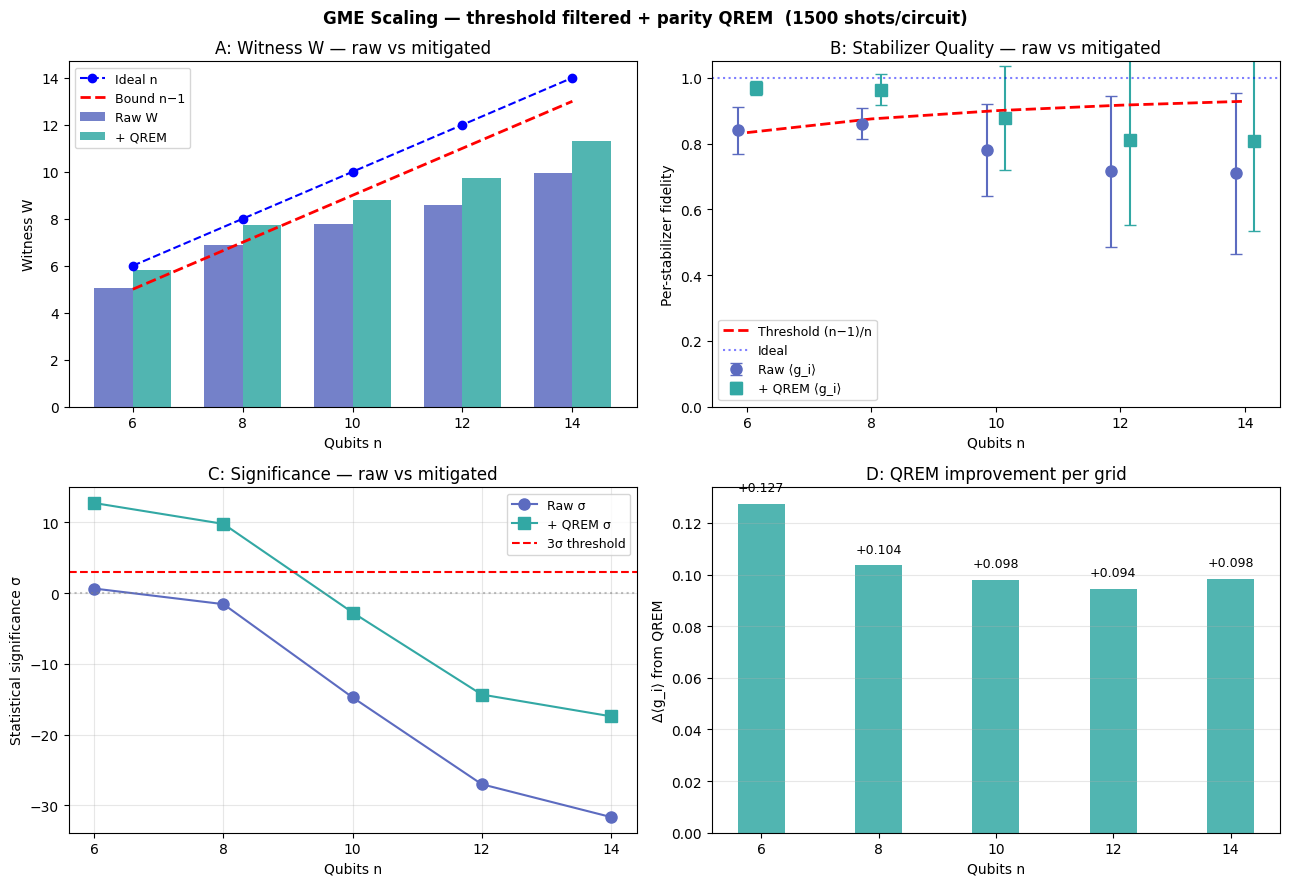

In [4]:
ns = [r['n'] for r in results]
W_raw = [r['W_raw'] for r in results]
W_mit = [r['W_mit'] for r in results]
ideals = [r['W_ideal'] for r in results]
bounds = [r['bound'] for r in results]
sigma_raw = [r['sigma_raw'] for r in results]
sigma_mit = [r['sigma_mit'] for r in results]
mean_raw = [r['stab_raw_mean'] for r in results]
std_raw  = [r['stab_raw_std']  for r in results]
mean_mit = [r['stab_mit_mean'] for r in results]
std_mit  = [r['stab_mit_std']  for r in results]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# A: W raw vs mitigated
ax = axes[0, 0]
x = np.arange(len(ns)); w = 0.35
b1 = ax.bar(x - w/2, W_raw,  w, color='#5c6bc0', alpha=0.85, label='Raw W')
b2 = ax.bar(x + w/2, W_mit,  w, color='#32a8a4', alpha=0.85, label='+ QREM')
ax.plot(x, ideals, 'b--o', label='Ideal n', markersize=6)
ax.plot(x, bounds, 'r--', label='Bound n−1', linewidth=2)
ax.set_xticks(x); ax.set_xticklabels([f'{n}' for n in ns])
ax.set_xlabel('Qubits n'); ax.set_ylabel('Witness W')
ax.set_title('A: Witness W — raw vs mitigated')
ax.legend(loc='upper left', fontsize=9)

# B: per-stabilizer fidelity
ax = axes[0, 1]
ax.errorbar(np.array(ns)-0.15, mean_raw, yerr=std_raw, fmt='o',
            color='#5c6bc0', label='Raw ⟨g_i⟩', markersize=8, capsize=4)
ax.errorbar(np.array(ns)+0.15, mean_mit, yerr=std_mit, fmt='s',
            color='#32a8a4', label='+ QREM ⟨g_i⟩', markersize=8, capsize=4)
ax.plot(ns, [(n-1)/n for n in ns], 'r--', label='Threshold (n−1)/n', linewidth=2)
ax.axhline(1.0, color='blue', linestyle=':', alpha=0.5, label='Ideal')
ax.set_xlabel('Qubits n'); ax.set_ylabel('Per-stabilizer fidelity')
ax.set_title('B: Stabilizer Quality — raw vs mitigated')
ax.set_xticks(ns); ax.set_ylim(0, 1.05)
ax.legend(loc='lower left', fontsize=9)

# C: significance
ax = axes[1, 0]
ax.plot(ns, sigma_raw, 'o-', color='#5c6bc0', label='Raw σ', markersize=8)
ax.plot(ns, sigma_mit, 's-', color='#32a8a4', label='+ QREM σ', markersize=8)
ax.axhline(3, color='red', linestyle='--', label='3σ threshold')
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Qubits n'); ax.set_ylabel('Statistical significance σ')
ax.set_title('C: Significance — raw vs mitigated')
ax.set_xticks(ns); ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# D: per-qubit improvement (Δ⟨g⟩ from QREM)
ax = axes[1, 1]
deltas = [m - r for m, r in zip(mean_mit, mean_raw)]
ax.bar(ns, deltas, color='#32a8a4', alpha=0.85)
for n, d in zip(ns, deltas):
    ax.text(n, d + 0.005, f'+{d:.3f}', ha='center', fontsize=9)
ax.set_xlabel('Qubits n'); ax.set_ylabel('Δ⟨g_i⟩ from QREM')
ax.set_title('D: QREM improvement per grid')
ax.set_xticks(ns); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f'GME Scaling — threshold filtered + parity QREM  ({SHOTS} shots/circuit)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('gme_scaling_mitigated.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-qubit heatmaps

For each grid, the per-qubit stabilizer expectation $\langle g_i \rangle$. Cells close to +1 (deep green) = perfect cluster behaviour at that qubit. Drops toward 0 reveal where noise concentrates.

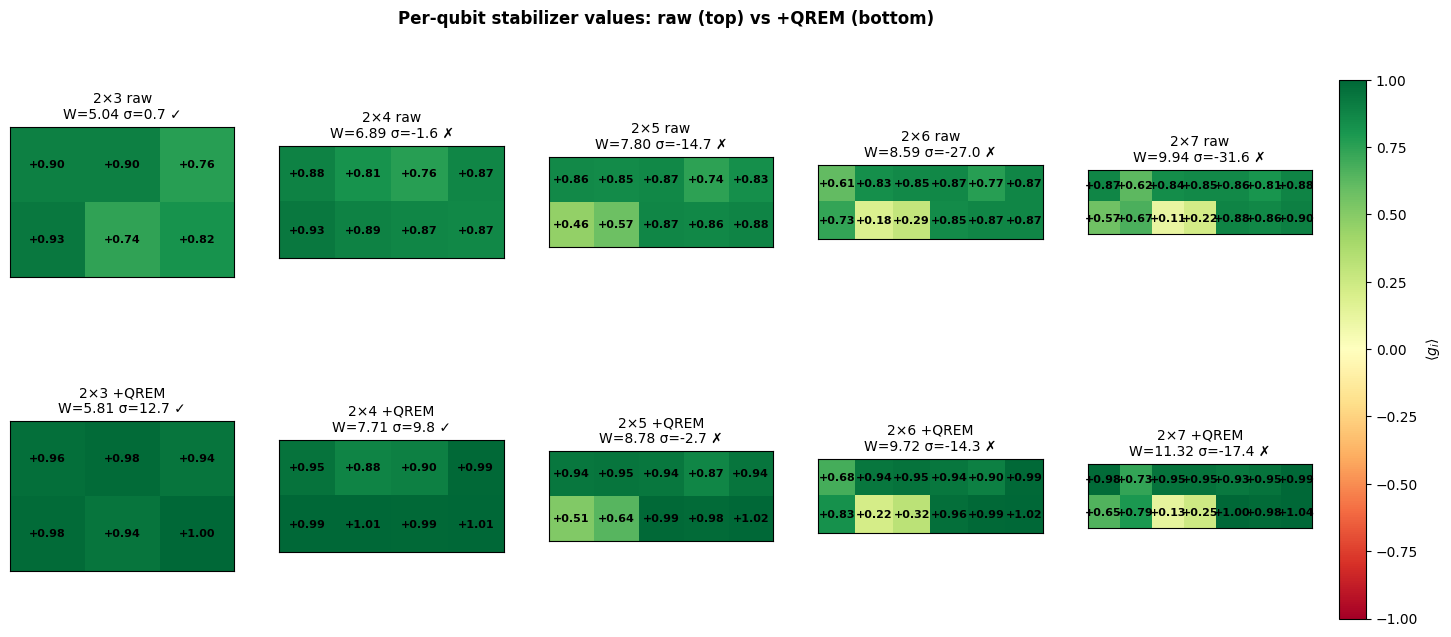

In [5]:
fig, axes = plt.subplots(2, len(results), figsize=(3.5*len(results), 7),
                          squeeze=False)
for col, r in enumerate(results):
    rows, cols = r['rows'], r['cols']
    for row_idx, (key, label) in enumerate([('stab_raw', 'raw'), ('stab_mit', '+QREM')]):
        ax = axes[row_idx, col]
        grid = np.array([[r[key][rr*cols+cc] for cc in range(cols)] for rr in range(rows)])
        im = ax.imshow(grid, vmin=-1, vmax=1, cmap='RdYlGn')
        for rr in range(rows):
            for cc in range(cols):
                ax.text(cc, rr, f'{grid[rr,cc]:+.2f}', ha='center', va='center',
                        fontsize=8, fontweight='bold')
        sigma = r['sigma_raw'] if key == 'stab_raw' else r['sigma_mit']
        W = r['W_raw'] if key == 'stab_raw' else r['W_mit']
        is_gme = r['is_gme_raw'] if key == 'stab_raw' else r['is_gme_mit']
        ax.set_title(f'{rows}×{cols} {label}\nW={W:.2f} σ={sigma:.1f} {"✓" if is_gme else "✗"}',
                     fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label=r'$\langle g_i \rangle$')
plt.suptitle('Per-qubit stabilizer values: raw (top) vs +QREM (bottom)',
             fontsize=12, fontweight='bold')
plt.savefig('gme_heatmaps_mitigated.png', dpi=150, bbox_inches='tight')
plt.show()

## Save results to JSON

Persist results so they can be re-loaded for later analysis without re-running on hardware.

In [6]:
import json
from datetime import datetime, timezone

out = {
    'timestamp': datetime.now(timezone.utc).isoformat(),
    'shots_per_circuit': SHOTS,
    'thresholds': THRESHOLDS,
    'backend': str(backend),
    'results': [
        {**r,
         'stab_raw': {str(k): v for k, v in r['stab_raw'].items()},
         'stab_mit': {str(k): v for k, v in r['stab_mit'].items()}}
        for r in results
    ],
}
with open('gme_scaling_mitigated_results.json', 'w') as f:
    json.dump(out, f, indent=2)
print('Saved gme_scaling_mitigated_results.json')

max_raw = max((r['n'] for r in results if r['is_gme_raw']), default=0)
max_mit = max((r['n'] for r in results if r['is_gme_mit']), default=0)
print(f'Max GME-certified (raw): {max_raw}')
print(f'Max GME-certified (+QREM): {max_mit}')

Saved gme_scaling_mitigated_results.json
Max GME-certified (raw): 6
Max GME-certified (+QREM): 8


## Key findings

Auto-derived from the captured data: largest certified n, average per-stabilizer fidelity, fit to extrapolate the breakdown point.

In [7]:
print('=' * 60)
print('KEY FINDINGS')
print('=' * 60)
max_raw = max((r['n'] for r in results if r['is_gme_raw']), default=0)
max_mit = max((r['n'] for r in results if r['is_gme_mit']), default=0)
print(f'  Max GME certified (raw)            : {max_raw} qubits')
print(f'  Max GME certified (+ parity QREM)  : {max_mit} qubits')
print()
print(f'  Mean ⟨g_i⟩ raw                     : {np.mean([r["stab_raw_mean"] for r in results]):.3f}')
print(f'  Mean ⟨g_i⟩ + QREM                  : {np.mean([r["stab_mit_mean"] for r in results]):.3f}')
print(f'  Average QREM lift                  : '
      f'{np.mean([r["stab_mit_mean"] - r["stab_raw_mean"] for r in results]):+.3f}')
print()
print('Per-grid summary:')
for r in results:
    print(f'  {r["rows"]}×{r["cols"]} ({r["n"]:>2}q):  '
          f'raw W={r["W_raw"]:.2f} σ={r["sigma_raw"]:6.2f} {"✓" if r["is_gme_raw"] else "✗"}   '
          f'+QREM W={r["W_mit"]:.2f} σ={r["sigma_mit"]:6.2f} {"✓" if r["is_gme_mit"] else "✗"}')

KEY FINDINGS
  Max GME certified (raw)            : 6 qubits
  Max GME certified (+ parity QREM)  : 8 qubits

  Mean ⟨g_i⟩ raw                     : 0.781
  Mean ⟨g_i⟩ + QREM                  : 0.886
  Average QREM lift                  : +0.104

Per-grid summary:
  2×3 ( 6q):  raw W=5.04 σ=  0.65 ✓   +QREM W=5.81 σ= 12.74 ✓
  2×4 ( 8q):  raw W=6.89 σ= -1.55 ✗   +QREM W=7.71 σ=  9.79 ✓
  2×5 (10q):  raw W=7.80 σ=-14.73 ✗   +QREM W=8.78 σ= -2.73 ✗
  2×6 (12q):  raw W=8.59 σ=-27.00 ✗   +QREM W=9.72 σ=-14.32 ✗
  2×7 (14q):  raw W=9.94 σ=-31.63 ✗   +QREM W=11.32 σ=-17.40 ✗
